Señal 1:
Simetría bilateral: 100.0%
Señal 2:
Simetría bilateral: 64.0%
Señal 3:
Simetría bilateral: 36.0%
Señal 4:
Simetría bilateral: 16.0%
Señal 5:
Simetría bilateral: 4.0%


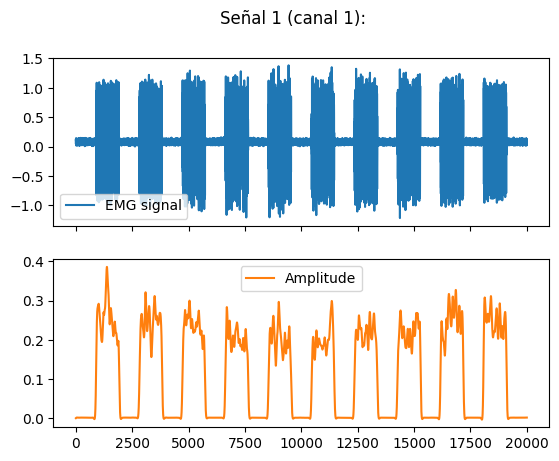

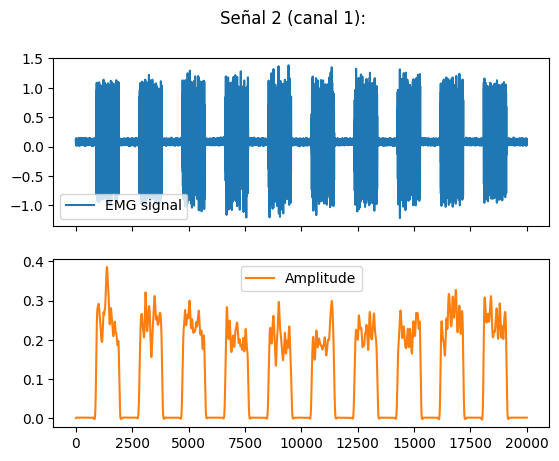

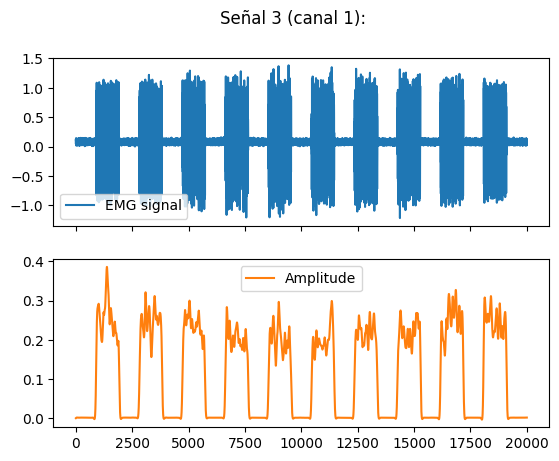

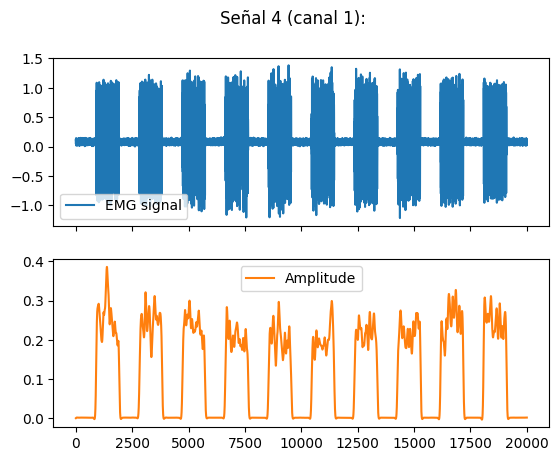

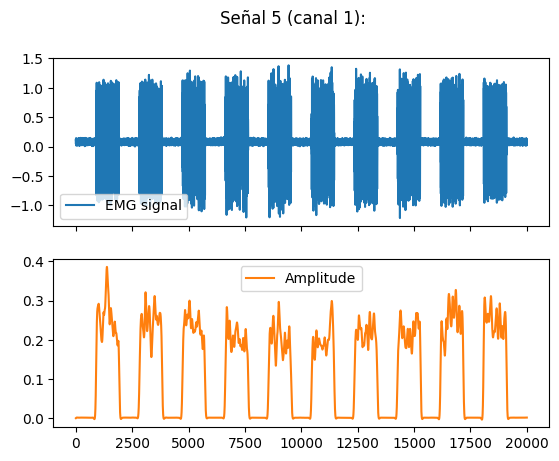

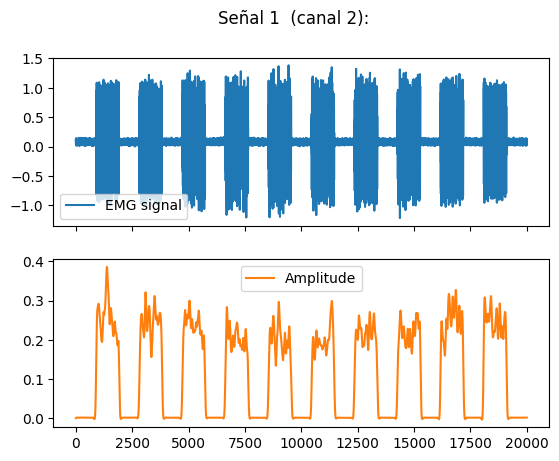

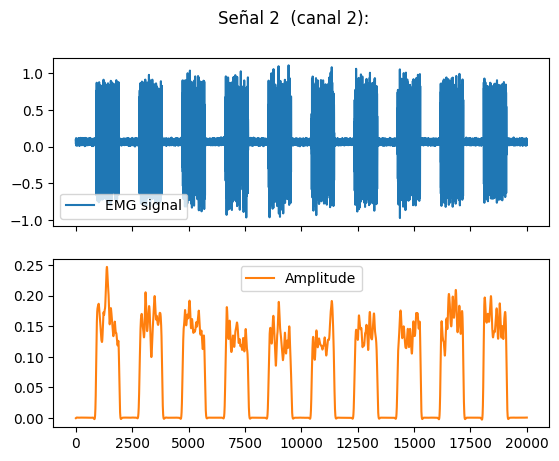

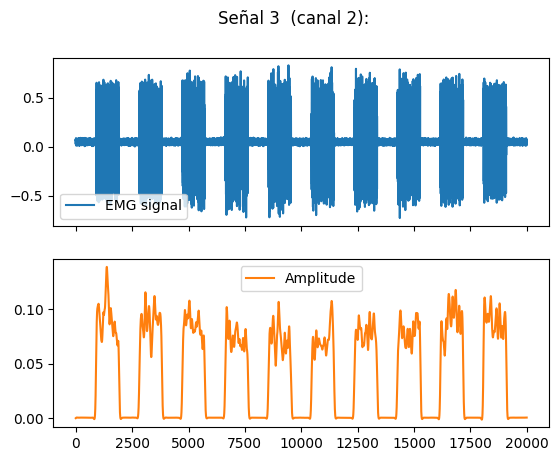

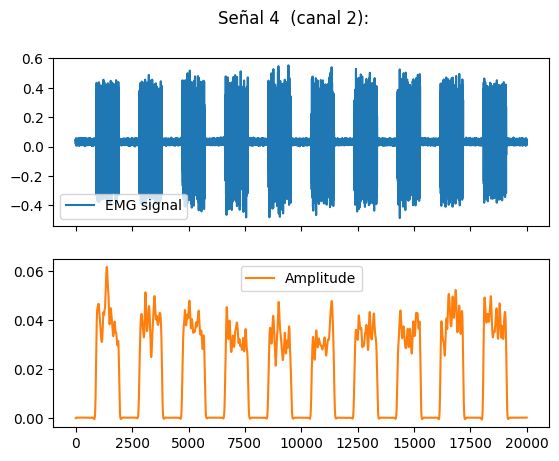

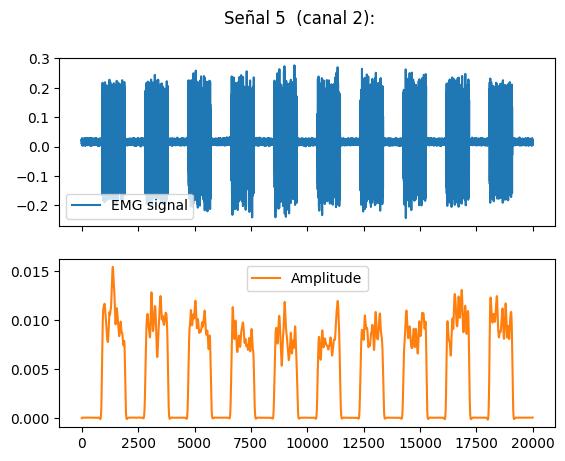

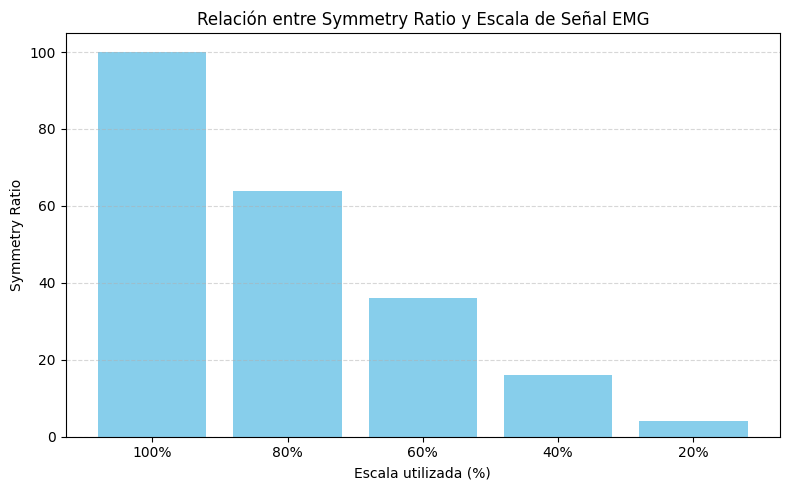

In [76]:

import neurokit2 as nk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


fs = 1000

EMG_signals = [];

# Generamos las 5 señales con 2 canales
for i in range(10):
  if i == 0:
    base_signal = nk.emg_simulate(duration=20, burst_number=10, burst_duration = 1, noise=0.01, sampling_rate=fs)
    EMG_signals.append(base_signal)
  elif i < 5:
    # 5 señales idénticas (canal 1)
    EMG_signals.append(base_signal)
  else:
    # señales escaladas en 1 0.8 0.6 0.4 0.2 (canal 2)
    f_escalamiento = -0.2*i +2
    EMG_signals.append(base_signal*f_escalamiento)

#EMG_signals = [emg1, emg2, emg3, emg4, emg5, emg1_2, emg2_2, emg3_2, emg4_2, emg5_2]

EMG_cleaned = []
Amplitudes = []

# Generamos las señales limpias y sus amplitudes
for signal in EMG_signals:
  cleaned = nk.emg_clean(signal, sampling_rate=1000)
  EMG_cleaned.append(cleaned)
  amplitude = nk.emg_amplitude(cleaned)
  Amplitudes.append(amplitude)

Symmetry_ratios = []

# Calculamos los symmetry ratios
for i in range(5):
  # media de la envolvente
  rms1 = np.mean(Amplitudes[i])
  rms2 = np.mean(Amplitudes[i+5])
  # symmetry ratio
  symmetry = (min(rms2, rms1) / max(rms2, rms1)) * 100
  Symmetry_ratios.append(symmetry)
  print(f"Señal {i+1}:")
  print(f"Simetría bilateral: {symmetry:.1f}%")



# Graficamos las señales limpias y sus amplitudes
for i in range(len(EMG_signals)):
  if i < 5:
    pd.DataFrame({"EMG signal": EMG_signals[i], "Amplitude": Amplitudes[i]}, ).plot(subplots=True, title="Señal " + str(i+1)+" (canal 1):")
  else:
    pd.DataFrame({"EMG signal": EMG_signals[i], "Amplitude": Amplitudes[i]}).plot(subplots=True, title="Señal " + str(i+1-5)+"  (canal 2):")

# Graficamos el Symmetry Ratio
escalas = [100, 80, 60, 40, 20]

plt.figure(figsize=(8, 5))
plt.bar([f"{i}%" for i in escalas], Symmetry_ratios, color="skyblue")

plt.xlabel("Escala utilizada (%)")
plt.ylabel("Symmetry Ratio")
plt.title("Relación entre Symmetry Ratio y Escala de Señal EMG")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
!pip install neurokit2